# Lab 1 - Iris Dataset - EDA + PCA

In [83]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

## Load the dataset

In [84]:
# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# Combine for convenience
df = X.copy()
df['species'] = y.iloc[:, 0].values

# Projector-friendly, high-contrast palette (colorblind-safe style)
species_palette = {
    'Iris-setosa': '#0072B2',      # strong blue
    'Iris-versicolor': '#E69F00',  # vivid orange
    'Iris-virginica': '#009E73'    # strong green
}

## EDA

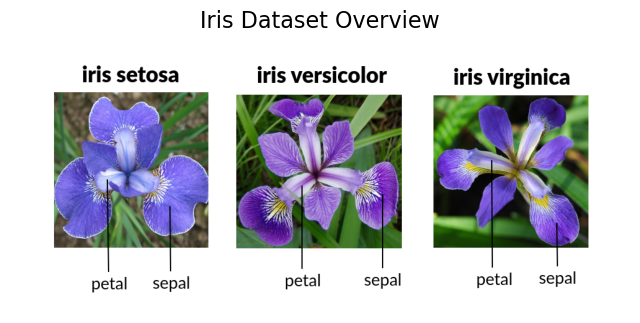

In [85]:
# display the ../iris.png picture
img = plt.imread('../../iris.png')
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Iris Dataset Overview', fontsize=16)
plt.show()


### 1. Dataset Overview

In [86]:
# Analyze instances and attributes
print(f"Number of instances (rows): {X.shape[0]}")
print(f"Number of attributes (columns): {X.shape[1]}")
print(f"\nFeature names: {list(X.columns)}")
print(f"\nData types:\n{X.dtypes}")

# First and last rows – sanity check on loading & ordering
print("\nFirst 5 rows:")
display(X.head())
print("\nLast 5 rows:")
display(X.tail())

# Display descriptive statistics of attributes
print("\nDescriptive statistics of attributes:")
display(X.describe())

# Analyze classes and their distribution
print("\nClass distribution in the dataset:")
print(df['species'].value_counts())


Number of instances (rows): 150
Number of attributes (columns): 4

Feature names: ['sepal length', 'sepal width', 'petal length', 'petal width']

Data types:
sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
dtype: object

First 5 rows:


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Last 5 rows:


,sepal length,sepal width,petal length,petal width
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8



Descriptive statistics of attributes:


,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class distribution in the dataset:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### 2. Missing Values

In [87]:
print("Missing values per feature:")
display(X.isnull().sum().rename("Missing Count").to_frame())
print(f"\nTotal missing values: {X.isnull().sum().sum()}")

# Duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")
if n_dupes > 0:
    print("Duplicated entries:")
    display(df[df.duplicated(keep=False)].sort_values(list(X.columns)))

# Zeros – floral measurements (length/width) can never be 0
print("\nZero counts per feature (physically impossible for floral measurements):")
display((X == 0).sum().rename("Zero Count").to_frame())

# Negative values – also impossible for these features
print("\nNegative value counts per feature:")
display((X < 0).sum().rename("Negative Count").to_frame())

# Common sentinel / placeholder values
for sentinel in [-1, -999, 9999, 999]:
    hits = (X == sentinel).sum().sum()
    if hits:
        print(f"\nSentinel value {sentinel} found {hits} time(s)")


Missing values per feature:


,Missing Count
sepal length,0
sepal width,0
petal length,0
petal width,0



Total missing values: 0

Duplicate rows: 3
Duplicated entries:


,sepal length,sepal width,petal length,petal width,species
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica



Zero counts per feature (physically impossible for floral measurements):


,Zero Count
sepal length,0
sepal width,0
petal length,0
petal width,0



Negative value counts per feature:


,Negative Count
sepal length,0
sepal width,0
petal length,0
petal width,0


### 3. Feature Distributions (Histograms + KDE)

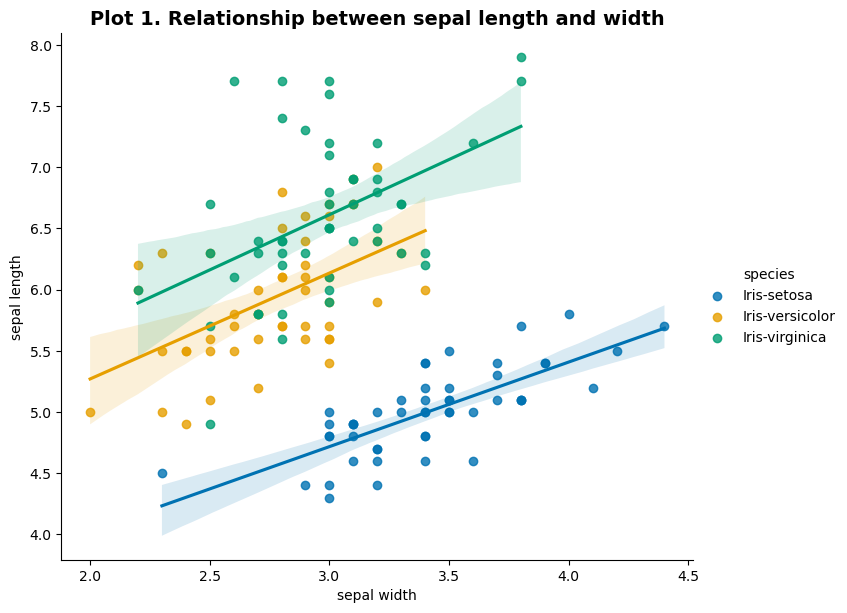

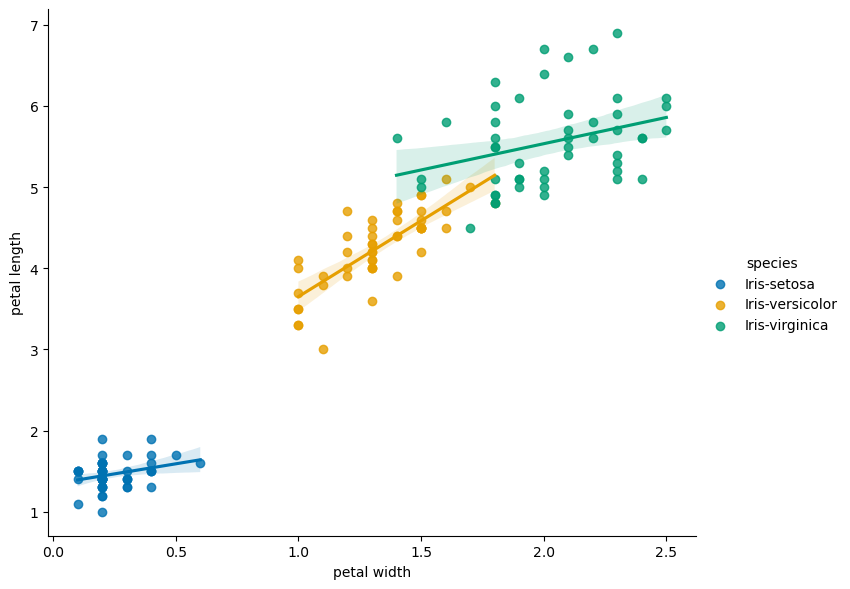

In [88]:
# 5.5 Mandatory Lab Plot 1: Sepal length vs width with regression lines
sns.lmplot(
    data=df,
    x='sepal width',
    y='sepal length',
    hue='species',
    palette=species_palette,
    fit_reg=True,
    height=6,
    aspect=1.2
)
plt.title('Plot 1. Relationship between sepal length and width', fontsize=14, fontweight='bold')
plt.show()

## add a plot for petal length vs width with regression lines
sns.lmplot(
    data=df,
    x='petal width',
    y='petal length',
    hue='species',
    palette=species_palette,
    fit_reg=True,
    height=6,
    aspect=1.2
)

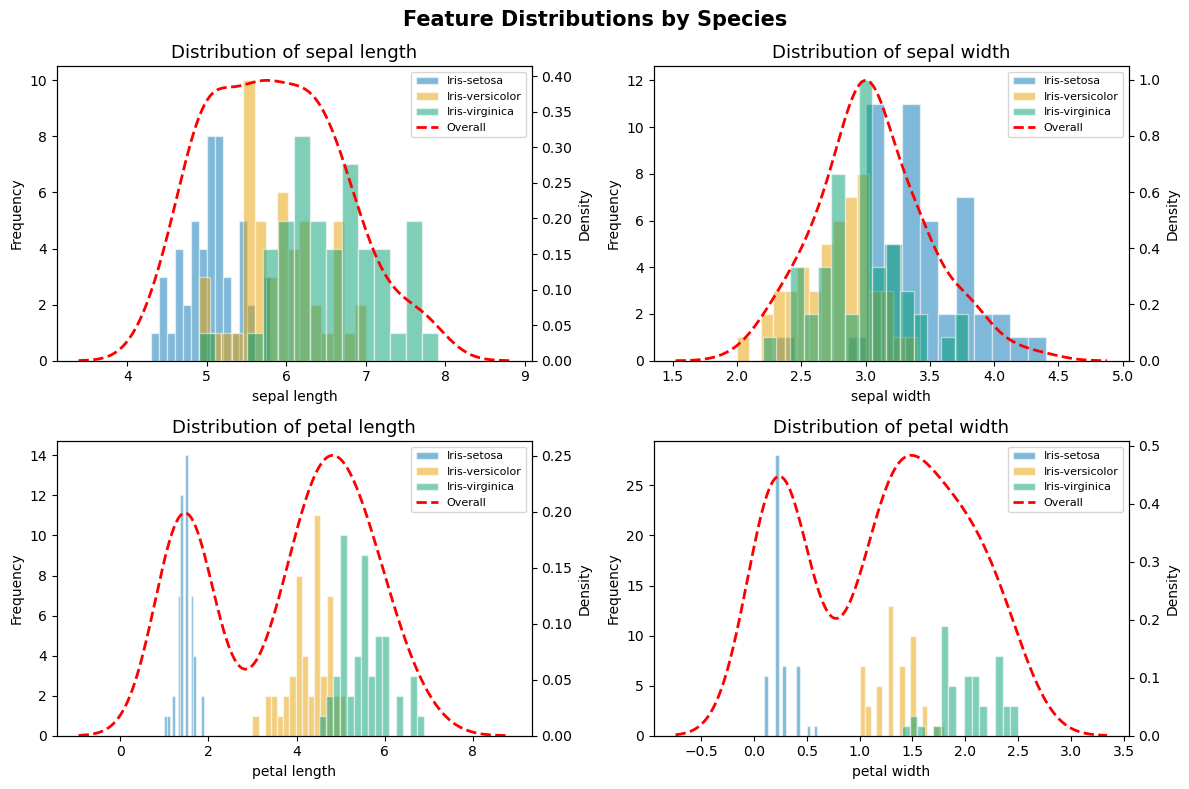

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    for species, group in df.groupby('species'):
        axes[i].hist(group[col], alpha=0.5, label=species, bins=15, edgecolor='white', color=species_palette[species])
    # Overall KDE on a twin axis so it doesn't distort the frequency scale
    ax2 = axes[i].twinx()
    sns.kdeplot(data=df, x=col, ax=ax2, color='red', linewidth=2, linestyle='--', label='Overall')
    ax2.set_ylabel('Density')
    ax2.tick_params(axis='y')
    # Merge legends from both axes
    handles1, labels1 = axes[i].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    axes[i].legend(handles1 + handles2, labels1 + labels2, fontsize=8)
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Boxplots per Feature by Species

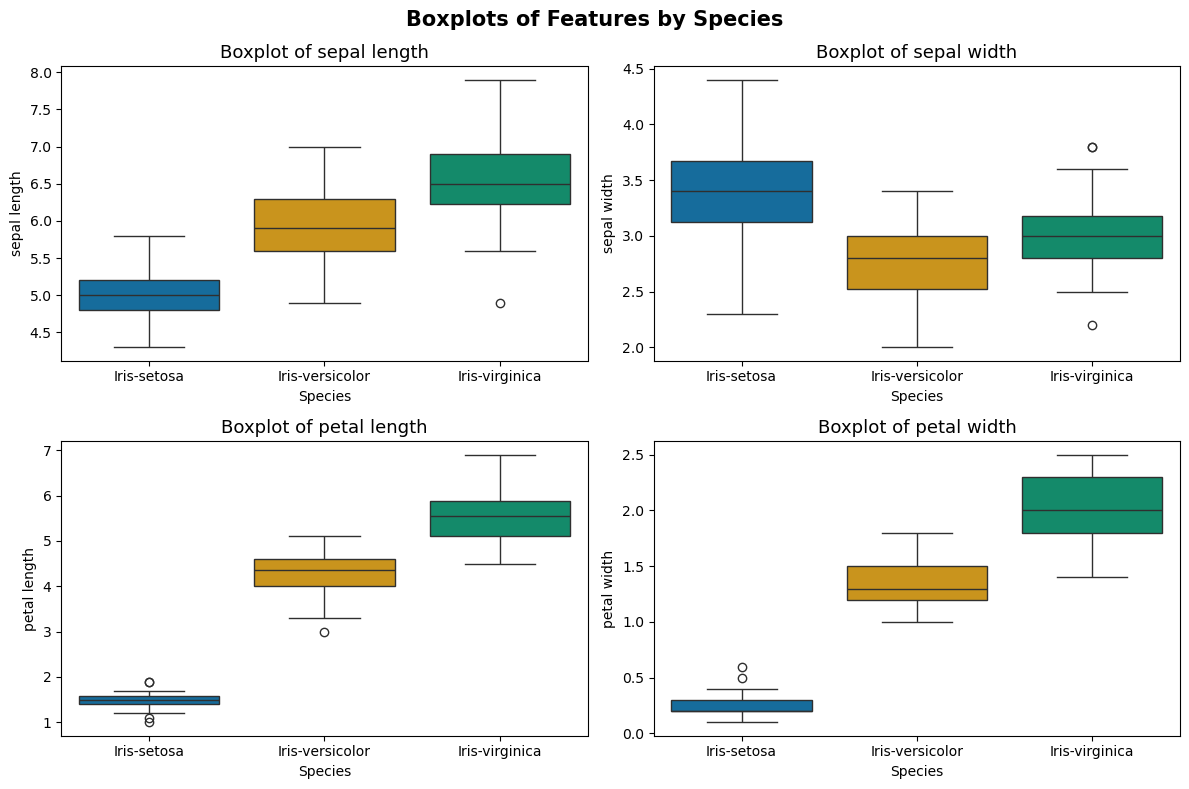

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(data=df, x='species', y=col, hue='species', palette=species_palette, legend=False, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=13)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots of Features by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Violin Plots per Feature by Species

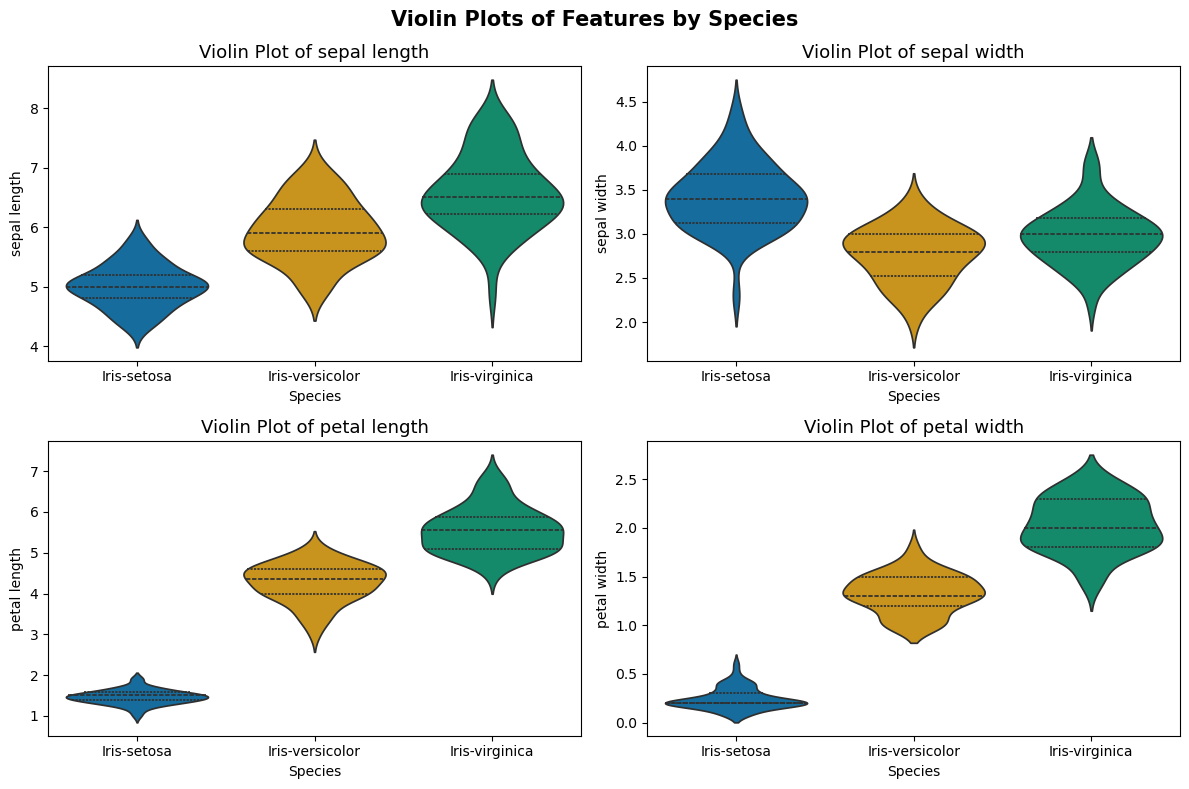

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.violinplot(data=df, x='species', y=col, hue='species', palette=species_palette, inner='quartile', legend=False, ax=axes[i])
    axes[i].set_title(f'Violin Plot of {col}', fontsize=13)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(col)

plt.suptitle('Violin Plots of Features by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Correlation Heatmap

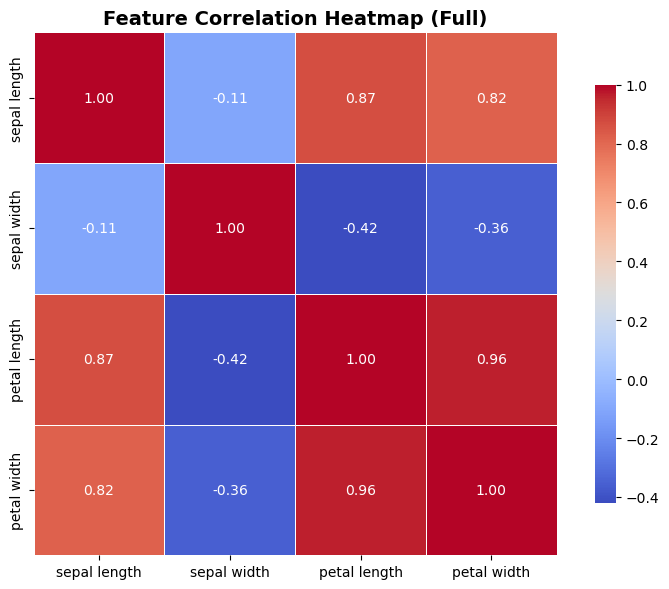

In [92]:
plt.figure(figsize=(8, 6))
corr = X.corr()

# Removed the mask parameter
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap (Full)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Notatki:
- heatmapa wskazuje na negatywną korelację między sepal length a sepal width **na całym zbiorze** - ale gdy rozdzielimy po gatunkach, dla każdego z nich korelacja jest dodatnia (zwłaszcza dla setosa).

### 7. PairGrid

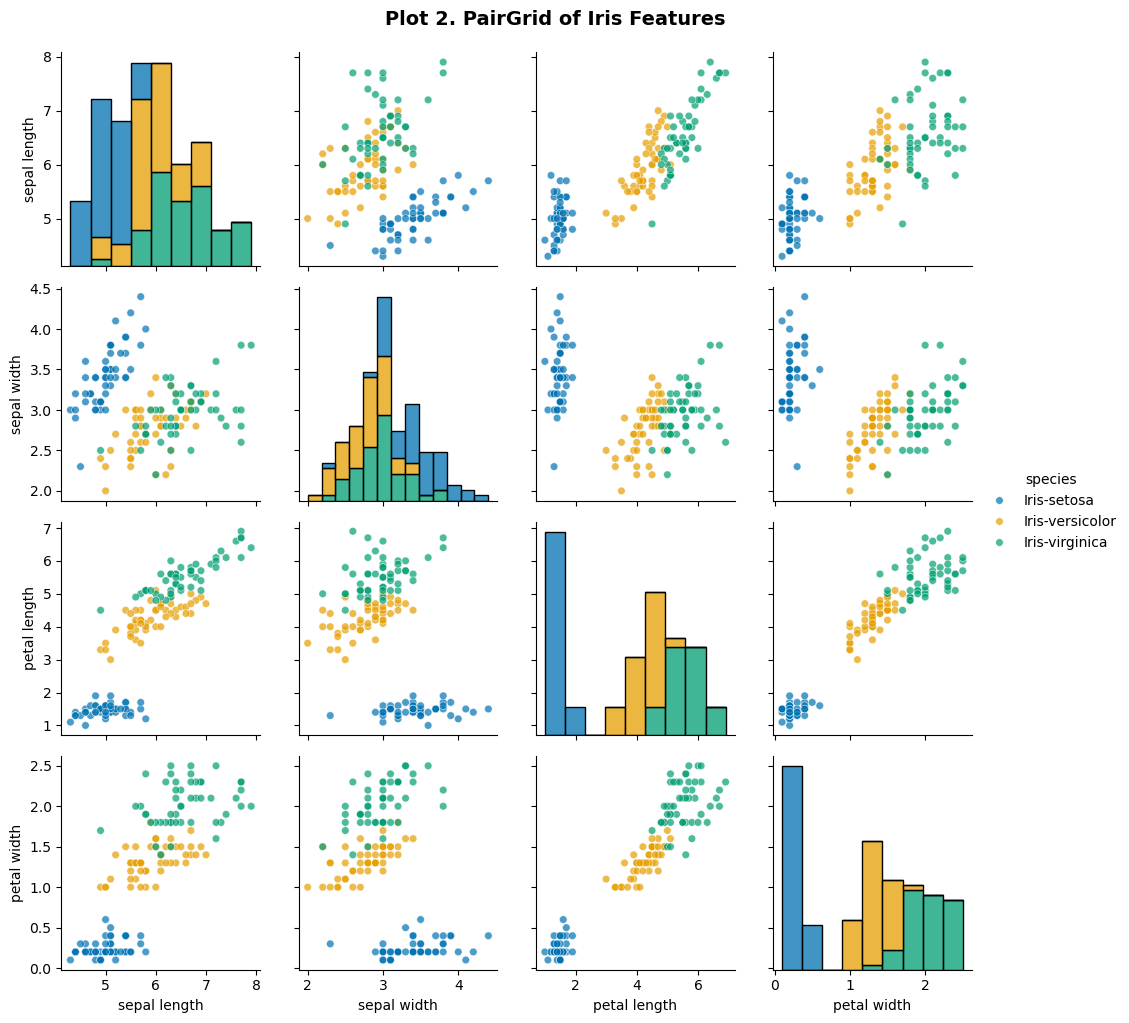

In [93]:
# 7. PairGrid (Lab mandatory Plot 2)
g = sns.PairGrid(df, hue='species', palette=species_palette, diag_sharey=False)

# Match the lab manual: stacked histograms on the diagonal
g.map_diag(sns.histplot, multiple="stack")

# Scatter plots off the diagonal
g.map_offdiag(sns.scatterplot, s=30, alpha=0.7)

g.add_legend()
g.fig.suptitle('Plot 2. PairGrid of Iris Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 8. Summary of Key Findings

- Setosę można bardzo łatwo oddzielić od versicolor i virginici - dolna część zakresu rozmiaru kielicha i płatka virginici pokrywa się z górną częścią zakresu versicoloru, lecz zazwyczaj virginica jest większa
- Jest bardzo silna korelacja między długością i szerokością płatka, zarówno w całym zbiorze (r~0,96) jak i dla pojedynczych gatunków
- Patrząc na cały zbiór, korelacja między długością i szerokością kielicha jest ujemna (r~0,11), jednak dla każdej z klas osobno jest dodatnia
- Dla Iris-setosa nie istnieje istotna zależność pomiędzy rozmimarami płatka i kielicha, dla versicolor i virginici widać pozytywną korelację

### 9. PCA (Principal Component Analysis)

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA with 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\nComponent loadings (contribution of each original feature):")
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)
display(loadings)


Explained variance ratio per component:
  PC1: 0.7277 (72.77%)
  PC2: 0.2303 (23.03%)
  Total variance retained: 95.80%

Component loadings (contribution of each original feature):


,PC1,PC2
sepal length,0.522372,0.372318
sepal width,-0.263355,0.925556
petal length,0.581254,0.021095
petal width,0.565611,0.065416


Why choose `n_components=2` before seeing the scree plot?

For Iris, we already have strong prior intuition from EDA and domain context:
- there are only 4 original features, and many are strongly correlated (especially petal length vs petal width),
- visual class separation is expected to be mostly visible in a 2D projection,
- a 2D PCA plot is directly interpretable and easy to compare with earlier 2D scatter plots.

So `n_components=2` is a practical visualization-first choice. The scree plot is then used as validation: it confirms whether 2 components retain enough variance for a faithful summary.

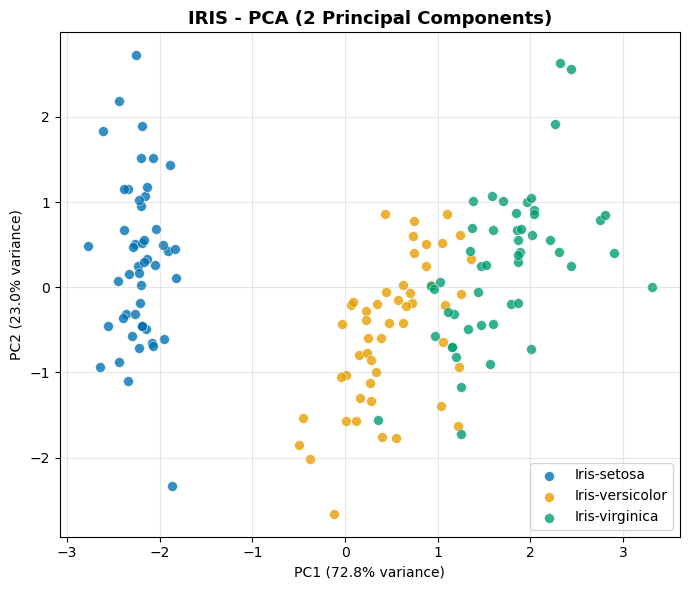

In [95]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['species'] = y.iloc[:, 0].values

# 2D scatter of principal components
plt.figure(figsize=(7, 6))
for species, group in pca_df.groupby('species'):
    plt.scatter(
        group['PC1'], group['PC2'],
        label=species, alpha=0.8, s=50,
        color=species_palette[species], edgecolors='white', linewidths=0.4
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title('IRIS - PCA (2 Principal Components)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

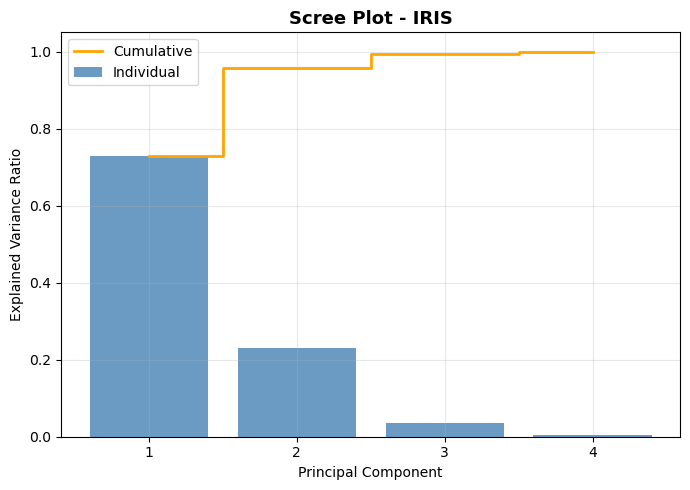

In [96]:
# Scree plot for explained variance across all principal components
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.bar(
    range(1, len(cumvar) + 1),
    pca_full.explained_variance_ratio_,
    color='steelblue', alpha=0.8, label='Individual'
)
plt.step(
    range(1, len(cumvar) + 1),
    cumvar, where='mid',
    color='orange', linewidth=2, label='Cumulative'
)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - IRIS', fontsize=13, fontweight='bold')
plt.xticks(range(1, len(cumvar) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

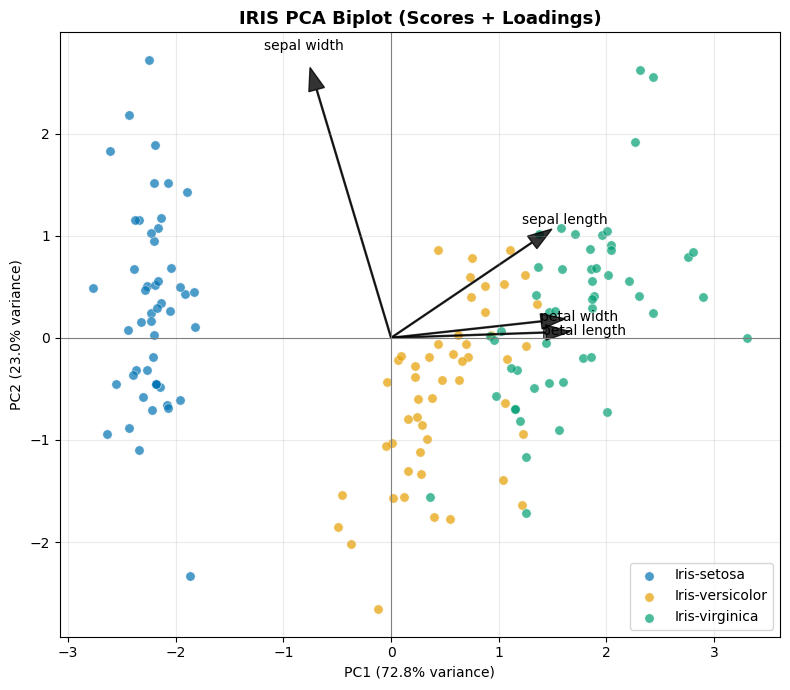

In [97]:
# Biplot: scores (samples in PC space) + loadings (feature directions)
fig, ax = plt.subplots(figsize=(8, 7))

# Scatter of sample scores
for species, group in pca_df.groupby('species'):
    ax.scatter(
        group['PC1'], group['PC2'],
        label=species, alpha=0.7, s=45,
        color=species_palette[species], edgecolors='white', linewidths=0.4
    )

# Scale loading vectors to fit score plot nicely
score_max = np.abs(X_pca[:, :2]).max()
loading_max = np.abs(pca.components_[:2, :]).max()
arrow_scale = 0.8 * score_max / loading_max

for i, feature in enumerate(X.columns):
    x_vec = pca.components_[0, i] * arrow_scale
    y_vec = pca.components_[1, i] * arrow_scale
    ax.arrow(0, 0, x_vec, y_vec, color='black', alpha=0.8, width=0.01, head_width=0.15, length_includes_head=True)
    ax.text(x_vec * 1.08, y_vec * 1.08, feature, fontsize=10, ha='center', va='center')

ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title('IRIS PCA Biplot (Scores + Loadings)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### 10. Feature Engineering: Combine Petal Length and Width into `petal size`

In this experiment, we replace `petal length` and `petal width` with one engineered feature:

- `petal size = petal length * petal width`

This gives a compact proxy for petal area and may reduce redundancy before PCA.

In [98]:
# Build transformed dataset
X_fe = X.copy()
X_fe['petal size'] = X_fe['petal length'] * X_fe['petal width']
X_fe = X_fe.drop(columns=['petal length', 'petal width'])

# Keep species label for plotting
fe_df = X_fe.copy()
fe_df['species'] = df['species'].values

print("Engineered feature set columns:", list(X_fe.columns))
print("\nPreview of transformed dataset:")
display(fe_df.head())

print("\nCorrelation matrix (engineered features):")
display(X_fe.corr())

Engineered feature set columns: ['sepal length', 'sepal width', 'petal size']

Preview of transformed dataset:


,sepal length,sepal width,petal size,species
0,5.1,3.5,0.28,Iris-setosa
1,4.9,3.0,0.28,Iris-setosa
2,4.7,3.2,0.26,Iris-setosa
3,4.6,3.1,0.30,Iris-setosa
4,5.0,3.6,0.28,Iris-setosa



Correlation matrix (engineered features):


,sepal length,sepal width,petal size
sepal length,1.000000,-0.109369,0.857326
sepal width,-0.109369,1.000000,-0.280612
petal size,0.857326,-0.280612,1.000000


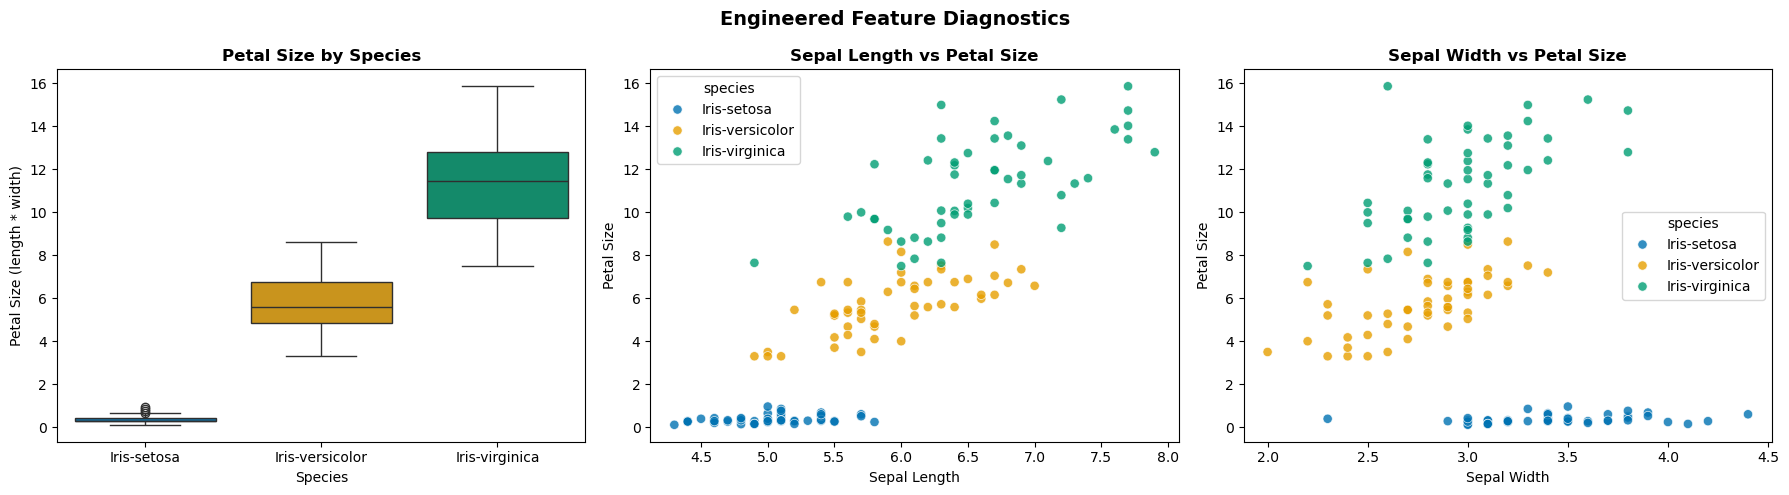

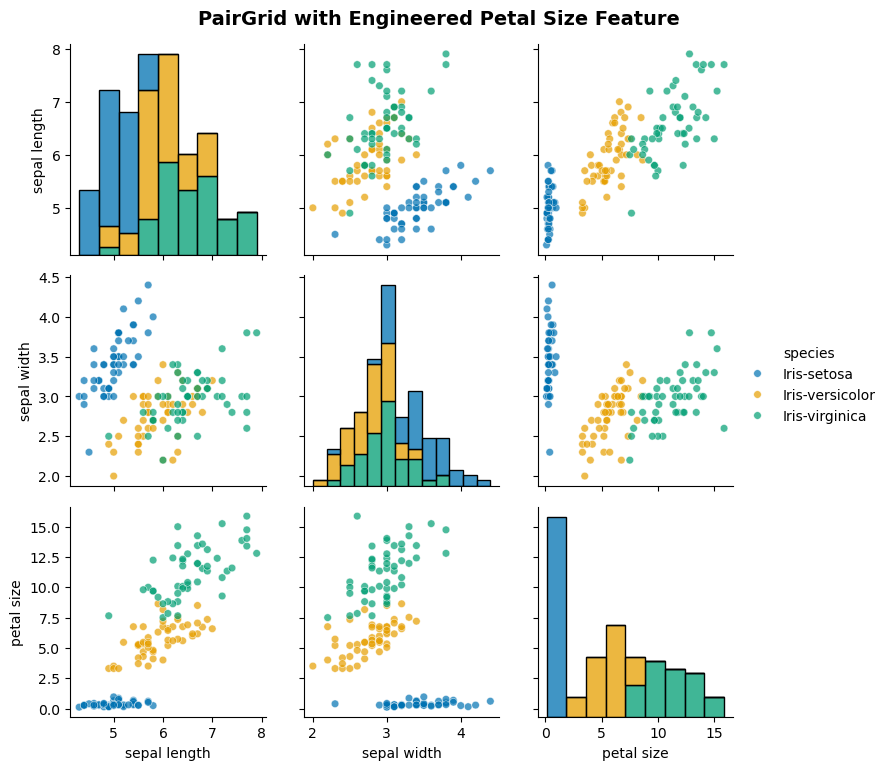

In [99]:
# Relevant plots for engineered feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Distribution of petal size by species
sns.boxplot(data=fe_df, x='species', y='petal size', hue='species', palette=species_palette, legend=False, ax=axes[0])
axes[0].set_title('Petal Size by Species', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Petal Size (length * width)')

# 2) Sepal length vs petal size
sns.scatterplot(data=fe_df, x='sepal length', y='petal size', hue='species', palette=species_palette, s=45, alpha=0.8, ax=axes[1])
axes[1].set_title('Sepal Length vs Petal Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Size')

# 3) Sepal width vs petal size
sns.scatterplot(data=fe_df, x='sepal width', y='petal size', hue='species', palette=species_palette, s=45, alpha=0.8, ax=axes[2])
axes[2].set_title('Sepal Width vs Petal Size', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sepal Width')
axes[2].set_ylabel('Petal Size')

plt.suptitle('Engineered Feature Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PairGrid on engineered feature set
g_fe = sns.PairGrid(fe_df, hue='species', palette=species_palette, diag_sharey=False)
g_fe.map_diag(sns.histplot, multiple='stack')
g_fe.map_offdiag(sns.scatterplot, s=30, alpha=0.7)
g_fe.add_legend()
g_fe.figure.suptitle('PairGrid with Engineered Petal Size Feature', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [100]:
# PCA on engineered features
scaler_fe = StandardScaler()
X_fe_scaled = scaler_fe.fit_transform(X_fe)

pca_fe = PCA(n_components=2)
X_fe_pca = pca_fe.fit_transform(X_fe_scaled)

print("Explained variance ratio (engineered feature set):")
for i, var in enumerate(pca_fe.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total variance retained: {pca_fe.explained_variance_ratio_.sum()*100:.2f}%")

print("\nComponent loadings (engineered feature set):")
loadings_fe = pd.DataFrame(
    pca_fe.components_.T,
    index=X_fe.columns,
    columns=['PC1', 'PC2']
)
display(loadings_fe)

pca_fe_df = pd.DataFrame(X_fe_pca, columns=['PC1', 'PC2'])
pca_fe_df['species'] = fe_df['species'].values

Explained variance ratio (engineered feature set):
  PC1: 0.6463 (64.63%)
  PC2: 0.3120 (31.20%)
  Total variance retained: 95.83%

Component loadings (engineered feature set):


,PC1,PC2
sepal length,0.664322,0.302924
sepal width,-0.283988,0.947932
petal size,0.691395,0.098297


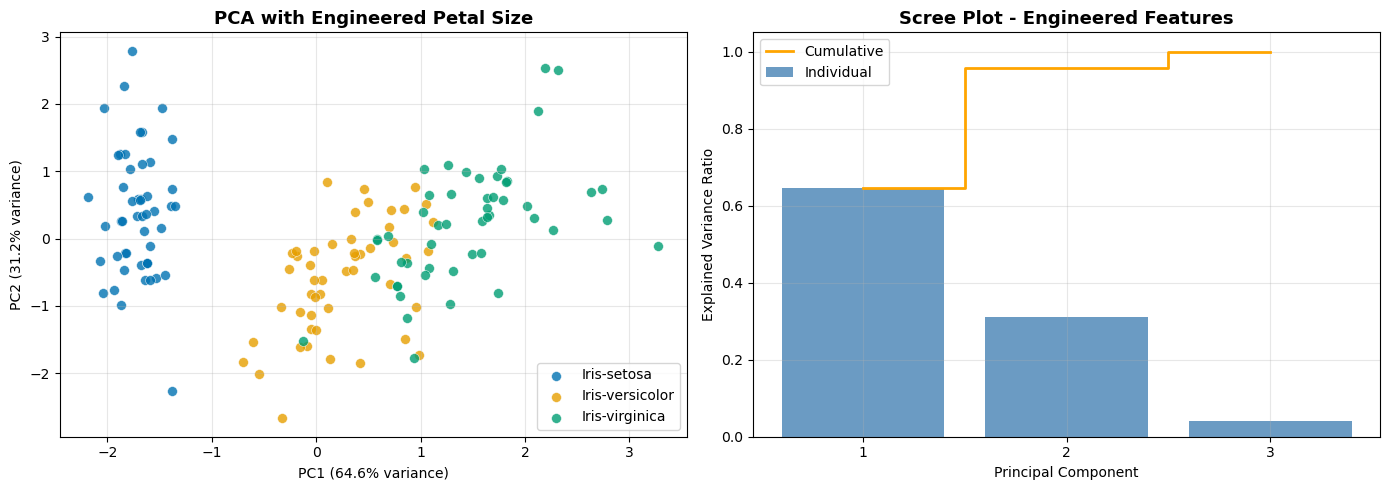

In [101]:
# PCA scatter + scree (engineered feature set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for species, group in pca_fe_df.groupby('species'):
    axes[0].scatter(
        group['PC1'], group['PC2'],
        label=species, alpha=0.8, s=50,
        color=species_palette[species], edgecolors='white', linewidths=0.4
    )
axes[0].set_xlabel(f"PC1 ({pca_fe.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_fe.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title('PCA with Engineered Petal Size', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

pca_fe_full = PCA().fit(X_fe_scaled)
cumvar_fe = np.cumsum(pca_fe_full.explained_variance_ratio_)
axes[1].bar(
    range(1, len(cumvar_fe) + 1),
    pca_fe_full.explained_variance_ratio_,
    color='steelblue', alpha=0.8, label='Individual'
)
axes[1].step(
    range(1, len(cumvar_fe) + 1),
    cumvar_fe, where='mid',
    color='orange', linewidth=2, label='Cumulative'
)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Scree Plot - Engineered Features', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, len(cumvar_fe) + 1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

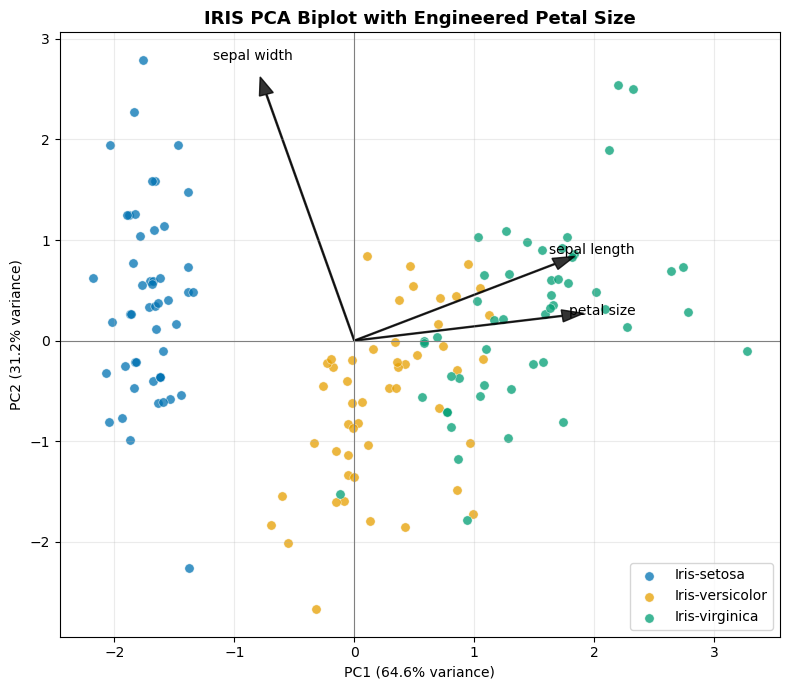

In [102]:
# Biplot for engineered feature set
fig, ax = plt.subplots(figsize=(8, 7))

for species, group in pca_fe_df.groupby('species'):
    ax.scatter(
        group['PC1'], group['PC2'],
        label=species, alpha=0.75, s=45,
        color=species_palette[species], edgecolors='white', linewidths=0.4
    )

score_max_fe = np.abs(X_fe_pca[:, :2]).max()
loading_max_fe = np.abs(pca_fe.components_[:2, :]).max()
arrow_scale_fe = 0.8 * score_max_fe / loading_max_fe

for i, feature in enumerate(X_fe.columns):
    x_vec = pca_fe.components_[0, i] * arrow_scale_fe
    y_vec = pca_fe.components_[1, i] * arrow_scale_fe
    ax.arrow(0, 0, x_vec, y_vec, color='black', alpha=0.8, width=0.01, head_width=0.12, length_includes_head=True)
    ax.text(x_vec * 1.08, y_vec * 1.08, feature, fontsize=10, ha='center', va='center')

ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel(f"PC1 ({pca_fe.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_fe.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title('IRIS PCA Biplot with Engineered Petal Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()